# 📊 TARDIS Automated Test Generation — Data Science Analysis

**วัตถุประสงค์:** วิเคราะห์ผลการทดลองสร้างชุดทดสอบอัตโนมัติด้วย TARDIS (Concolic/Symbolic Execution) บนชุดข้อมูลบั๊กจริงจาก **Defects4J** ครอบคลุม 17 โปรเจกต์โอเพนซอร์ส

**ไฟล์ข้อมูลที่ใช้:**
1. `Coverage_Result_All.csv` — ผลลัพธ์ระดับบั๊ก (ความครอบคลุม, ขนาดเทสต์, ประสิทธิภาพ)
2. `TARDIS_Extended_Result.csv` — ผลลัพธ์ระดับคลาส/เมธอดดิบ (สถานะการรัน, เวลา, ข้อผิดพลาด)

---

## 0. Setup และโหลดข้อมูล (Data Loading)

**เหตุผล:** ติดตั้ง Library และกำหนดค่าเริ่มต้น พร้อมทำ Type Conversion ให้ถูกต้องก่อนวิเคราะห์

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# --- Paths (Auto-detect dynamic path instead of hardcoded) ---
current_dir = Path.cwd()
possible_dirs = [
    Path(os.environ.get('TARDIS_RESULT_DIR', '')),
    current_dir.parent / 'result_csv',      # เมื่อรันจาก data_analysis/
    current_dir / 'result_csv',             # เมื่อรันจาก Tardis/
    current_dir / 'Tardis' / 'result_csv',  # เมื่อรันจาก project root
    current_dir.parent / 'result',          # รองรับโครงสร้างเดิม
    current_dir / 'result',
]

RESULT_DIR = next((p for p in possible_dirs if p.exists() and (p / 'Coverage_Result_All.csv').exists()), None)
if RESULT_DIR is None:
    RESULT_DIR = Path('../result_csv')

COV_PATH = RESULT_DIR / 'Coverage_Result_All.csv'
EXT_PATH = RESULT_DIR / 'TARDIS_Extended_Result.csv'
if not EXT_PATH.exists() and (RESULT_DIR.parent / 'TARDIS_Extended_Result.csv').exists():
    EXT_PATH = RESULT_DIR.parent / 'TARDIS_Extended_Result.csv'

# --- Load Coverage CSV ---
cov_raw = pd.read_csv(COV_PATH)

# Convert numeric columns (บาง row มีค่า 'NaN' เป็น string)
numeric_cols = ['Line_Coverage(%)', 'Branch_Coverage(%)', 'Covered_Lines', 'Total_Lines',
                'Covered_Branches', 'Total_Branches', 'Failing_Tests', 'Test_Suite_LOC',
                'Test_ExecTime_sec', 'Total_ExecTime_sec']
for c in numeric_cols:
    cov_raw[c] = pd.to_numeric(cov_raw[c], errors='coerce')

# --- Load Extended Result CSV ---
ext_raw = pd.read_csv(EXT_PATH)
ext_raw['ExecTime_sec'] = pd.to_numeric(ext_raw['ExecTime_sec'], errors='coerce')
ext_raw['SavedTestsCount'] = pd.to_numeric(ext_raw['SavedTestsCount'], errors='coerce')

print(f'Coverage CSV: {cov_raw.shape[0]:,} rows x {cov_raw.shape[1]} columns')
print(f'Extended CSV: {ext_raw.shape[0]:,} rows x {ext_raw.shape[1]} columns')
cov_raw.head(3)

Coverage CSV: 854 rows x 18 columns
Extended CSV: 8,661 rows x 9 columns


,Project,BugID,Total_Classes_Merged,Total_Methods_Merged,Test_Suite_LOC,Test_ExecTime_sec,Line_Coverage(%),Branch_Coverage(%),Covered_Lines,Total_Lines,Covered_Branches,Total_Branches,Failing_Tests,Fault_Detected,Runner_Status,Runner_Error,Total_ExecTime_sec,TimeoutLimit
0,Chart,1,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SETUP_FAIL | TIMEOUT,Unknown CLI Error | เกินเวลา 120 วินาที,120.0,0 | 120
1,Chart,2,1,1,340,6.15,2.2,1.3,18.0,801.0,7.0,544.0,0.0,NO,DOCKER_FAIL | SUCCESS_ON_TIMEOUT,ERR: | OUT: t be found in this WSL 2 distro. ...,200.0,120
2,Chart,3,1,1,571,5.75,6.1,2.2,23.0,380.0,4.0,186.0,1.0,YES,SETUP_FAIL | TIMEOUT,Unknown CLI Error | เกินเวลา 120 วินาที (เซฟทั...,120.0,0 | 120


## 1. ภาพรวมสถานะการรัน TARDIS (Execution Status Overview)

**ที่มา (Why):** ก่อนดูผลลัพธ์เชิงคุณภาพ ต้องเข้าใจก่อนว่า TARDIS "สำเร็จ" กี่เปอร์เซ็นต์ "ล้มเหลว" กี่เปอร์เซ็นต์ และล้มเหลวเพราะอะไร เพราะสถานะการรันเป็นตัวกำหนดความน่าเชื่อถือของผลลัพธ์ทั้งหมด

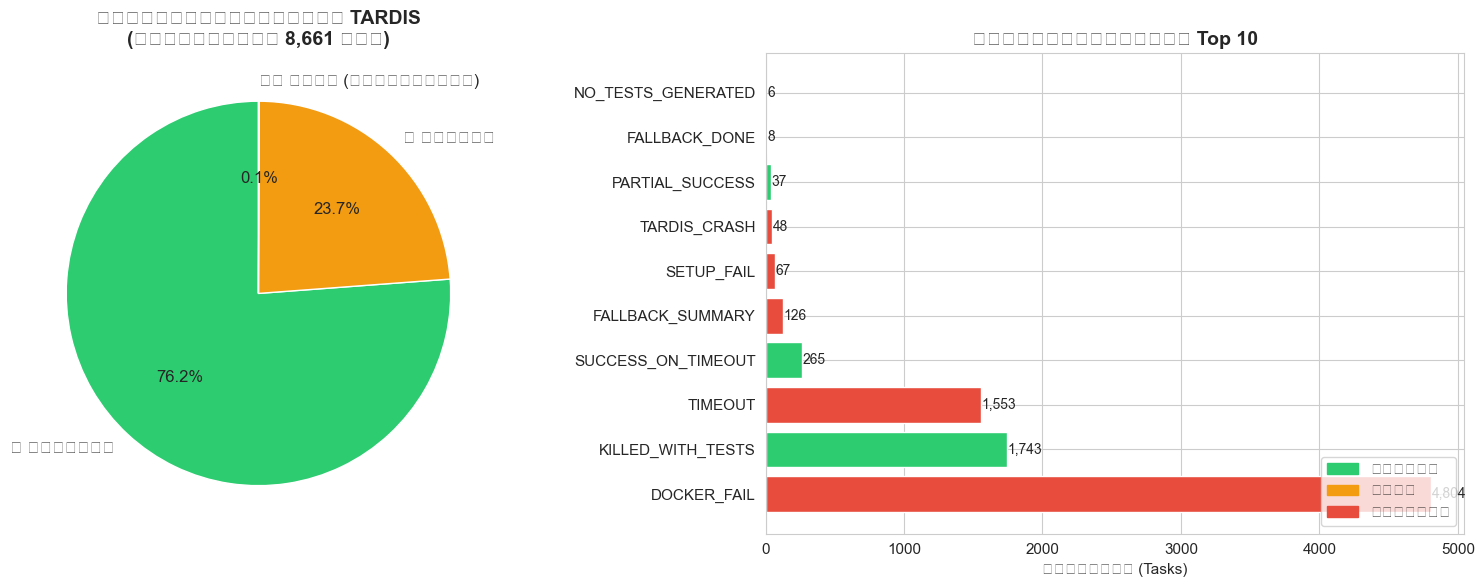


📌 สรุปความหมาย:
  ✅ สำเร็จ  2,056 งาน → TARDIS สร้างเทสต์ได้อย่างน้อยบางส่วน
  ⏭️ ข้าม    6 งาน → คลาสนั้นไม่มีโค้ดที่แก้จาก Bug หรือเทสต์ไม่ถูกเจน
  ❌ ล้มเหลว 6,599 งาน → หมดเวลา, Docker Error, หรือ Setup ผิดพลาด


In [2]:
# นับสถานะการรัน
status_counts = ext_raw['Status'].value_counts()

# จัดกลุ่มความหมาย
success_statuses = {'COMPLETED', 'SUCCESS_ON_TIMEOUT', 'KILLED_WITH_TESTS', 'PARTIAL_SUCCESS', 'FALLBACK_DONE'}
skip_statuses    = {'NO_MODIFIED_CLASSES', 'NO_TESTS_GENERATED'}
fail_statuses    = {'TIMEOUT', 'SETUP_FAIL', 'DOCKER_FAIL', 'CLASSLEVEL_CRASH'}

def classify_status(s):
    if s in success_statuses: return '✅ สำเร็จ'
    if s in skip_statuses:    return '⏭️ ข้าม (ไม่มีเทสต์)'
    return '❌ ล้มเหลว'

ext_raw['Status_Group'] = ext_raw['Status'].apply(classify_status)
group_counts = ext_raw['Status_Group'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# แผนภูมิ 1: Pie Chart สถานะกลุ่มใหญ่
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].pie(group_counts.values, labels=group_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('ภาพรวมสถานะการรัน TARDIS\n(จากทั้งหมด {:,} งาน)'.format(len(ext_raw)), fontsize=14, fontweight='bold')

# แผนภูมิ 2: Bar Chart สถานะแยกละเอียด
top_statuses = status_counts.head(10)
bar_colors = ['#2ecc71' if s in success_statuses else ('#f39c12' if s in skip_statuses else '#e74c3c')
              for s in top_statuses.index]
bars = axes[1].barh(range(len(top_statuses)), top_statuses.values, color=bar_colors, edgecolor='white')
axes[1].set_yticks(range(len(top_statuses)))
axes[1].set_yticklabels(top_statuses.index)
axes[1].set_xlabel('จำนวนงาน (Tasks)')
axes[1].set_title('รายละเอียดสถานะ Top 10', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_statuses.values):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)

legend_patches = [mpatches.Patch(color='#2ecc71', label='สำเร็จ'),
                  mpatches.Patch(color='#f39c12', label='ข้าม'),
                  mpatches.Patch(color='#e74c3c', label='ล้มเหลว')]
axes[1].legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.savefig('01_status_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 สรุปความหมาย:')
print(f'  ✅ สำเร็จ  {group_counts.get("✅ สำเร็จ", 0):,} งาน → TARDIS สร้างเทสต์ได้อย่างน้อยบางส่วน')
print(f'  ⏭️ ข้าม    {group_counts.get("⏭️ ข้าม (ไม่มีเทสต์)", 0):,} งาน → คลาสนั้นไม่มีโค้ดที่แก้จาก Bug หรือเทสต์ไม่ถูกเจน')
print(f'  ❌ ล้มเหลว {group_counts.get("❌ ล้มเหลว", 0):,} งาน → หมดเวลา, Docker Error, หรือ Setup ผิดพลาด')

## 2. อัตราความสำเร็จรายโปรเจกต์ (Success Rate per Project)

**ที่มา (Why):** แต่ละโปรเจกต์ใน Defects4J มีโครงสร้างโค้ดที่ซับซ้อนต่างกัน การดูอัตราความสำเร็จรายโปรเจกต์ช่วยให้เห็นว่า TARDIS เหมาะสำหรับโปรเจกต์ประเภทใดมากกว่ากัน

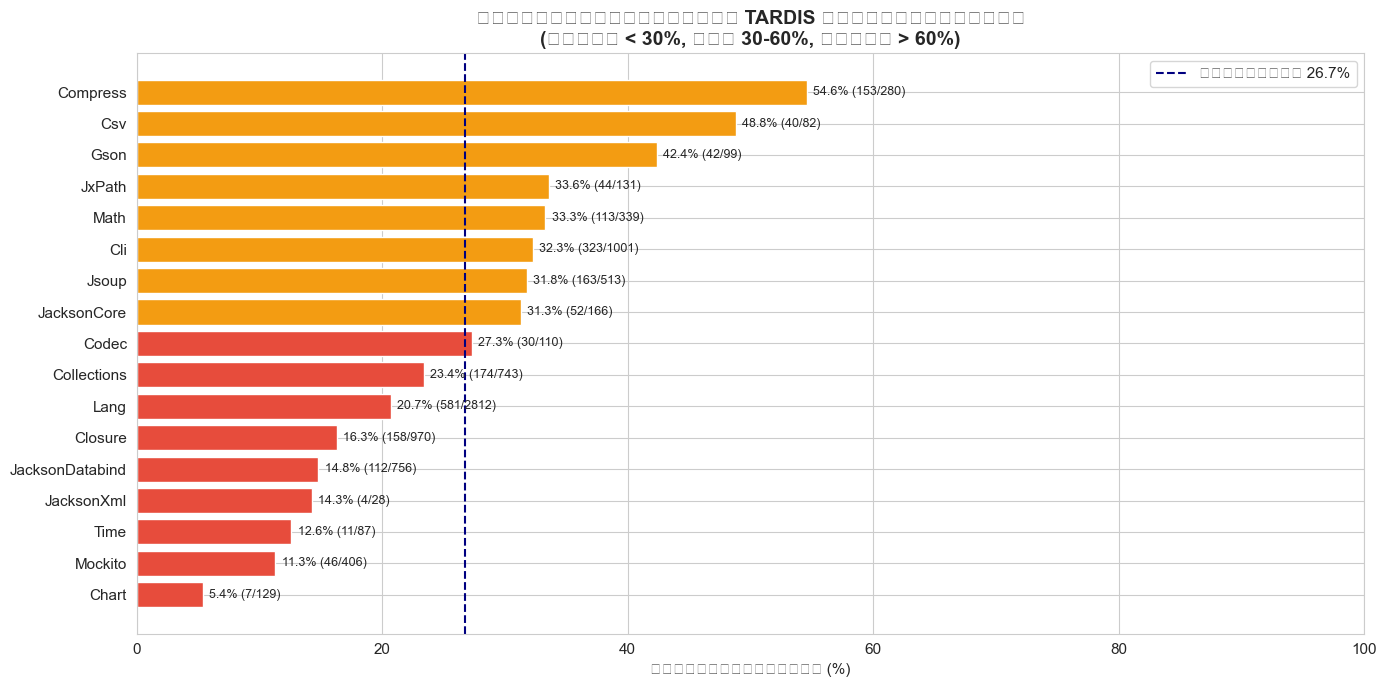


📌 สรุปความหมาย:
  - โปรเจกต์ที่ TARDIS ทำได้ดีที่สุด: Compress (54.6%)
  - โปรเจกต์ที่ TARDIS ทำได้แย่ที่สุด: Chart (5.4%)
  - ค่าเฉลี่ยโดยรวม: 26.7%
  - โปรเจกต์ที่ซับซ้อน (เช่น Closure) มักมีอัตราความสำเร็จต่ำกว่า เพราะ Path Condition ซับซ้อนเกินไปสำหรับ Z3 Solver


In [3]:
ext_raw['is_success'] = ext_raw['Status'].isin(success_statuses)
proj_stats = ext_raw.groupby('Project').agg(
    total=('Status', 'count'),
    success=('is_success', 'sum')
).reset_index()
proj_stats['success_rate'] = (proj_stats['success'] / proj_stats['total'] * 100).round(1)
proj_stats = proj_stats.sort_values('success_rate', ascending=True)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#e74c3c' if r < 30 else '#f39c12' if r < 60 else '#2ecc71'
          for r in proj_stats['success_rate']]
bars = ax.barh(proj_stats['Project'], proj_stats['success_rate'], color=colors, edgecolor='white')

for bar, (_, row) in zip(bars, proj_stats.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['success_rate']}% ({int(row['success'])}/{int(row['total'])})",
            va='center', fontsize=9)

ax.axvline(x=proj_stats['success_rate'].mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f"ค่าเฉลี่ย {proj_stats['success_rate'].mean():.1f}%")
ax.set_xlabel('อัตราความสำเร็จ (%)')
ax.set_title('อัตราความสำเร็จของ TARDIS แยกตามโปรเจกต์\n(สีแดง < 30%, ส้ม 30-60%, เขียว > 60%)', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('02_success_rate_per_project.png', dpi=150, bbox_inches='tight')
plt.show()

best = proj_stats.iloc[-1]
worst = proj_stats.iloc[0]
print('\n📌 สรุปความหมาย:')
print(f'  - โปรเจกต์ที่ TARDIS ทำได้ดีที่สุด: {best["Project"]} ({best["success_rate"]}%)')
print(f'  - โปรเจกต์ที่ TARDIS ทำได้แย่ที่สุด: {worst["Project"]} ({worst["success_rate"]}%)')
print(f'  - ค่าเฉลี่ยโดยรวม: {proj_stats["success_rate"].mean():.1f}%')
print('  - โปรเจกต์ที่ซับซ้อน (เช่น Closure) มักมีอัตราความสำเร็จต่ำกว่า เพราะ Path Condition ซับซ้อนเกินไปสำหรับ Z3 Solver')

## 3. การกระจายตัวของ Line Coverage และ Branch Coverage

**ที่มา (Why):** Coverage คือตัวชี้วัดหลักของคุณภาพชุดทดสอบ การดูการกระจายตัว (Distribution) บอกให้รู้ว่าเทสต์ที่สร้างขึ้นครอบคลุมโค้ดได้จริงมากน้อยแค่ไหนโดยเฉลี่ย

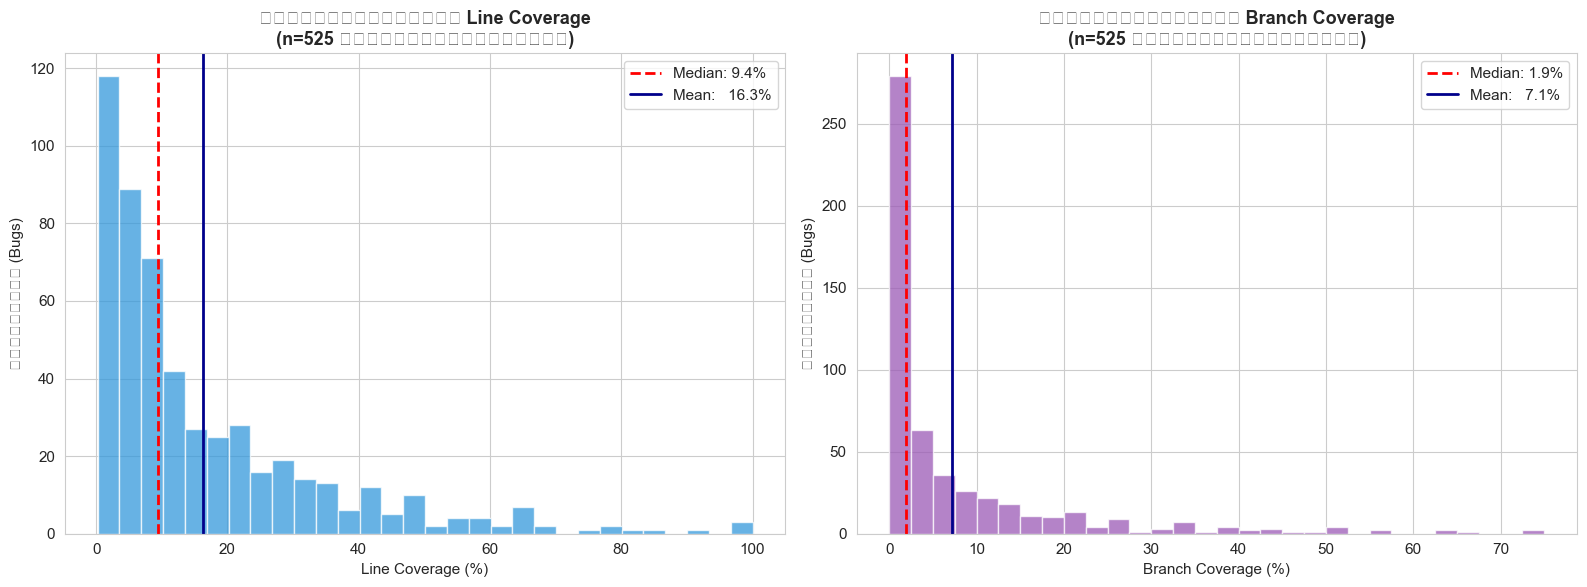


📌 สรุปความหมาย:
  Line Coverage   — ค่าเฉลี่ย: 16.3%, มัธยฐาน: 9.4%, สูงสุด: 100.0%
  Branch Coverage — ค่าเฉลี่ย: 7.1%, มัธยฐาน: 1.9%, สูงสุด: 75.0%
  - การกระจายตัวเบ้ขวา (Right-skewed) → บั๊กส่วนใหญ่ได้ Coverage ต่ำ แต่มีส่วนหนึ่งที่ TARDIS ทำได้ดีมาก
  - Branch Coverage มักต่ำกว่า Line Coverage เสมอ เพราะการครอบคลุมเงื่อนไข (Condition) ยากกว่า


In [4]:
cov_valid = cov_raw.dropna(subset=['Line_Coverage(%)', 'Branch_Coverage(%)'])
cov_valid = cov_valid[(cov_valid['Line_Coverage(%)'] > 0) | (cov_valid['Branch_Coverage(%)'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, color, label in [
    (axes[0], 'Line_Coverage(%)',   '#3498db', 'Line Coverage'),
    (axes[1], 'Branch_Coverage(%)', '#9b59b6', 'Branch Coverage')
]:
    data = cov_valid[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {data.median():.1f}%')
    ax.axvline(data.mean(),   color='darkblue', linestyle='-',  linewidth=2, label=f'Mean:   {data.mean():.1f}%')
    ax.set_xlabel(f'{label} (%)')
    ax.set_ylabel('จำนวนบั๊ก (Bugs)')
    ax.set_title(f'การกระจายตัวของ {label}\n(n={len(data):,} บั๊กที่มีชุดทดสอบ)', fontsize=13, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('03_coverage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

line_data   = cov_valid['Line_Coverage(%)'].dropna()
branch_data = cov_valid['Branch_Coverage(%)'].dropna()
print('\n📌 สรุปความหมาย:')
print(f'  Line Coverage   — ค่าเฉลี่ย: {line_data.mean():.1f}%, มัธยฐาน: {line_data.median():.1f}%, สูงสุด: {line_data.max():.1f}%')
print(f'  Branch Coverage — ค่าเฉลี่ย: {branch_data.mean():.1f}%, มัธยฐาน: {branch_data.median():.1f}%, สูงสุด: {branch_data.max():.1f}%')
print('  - การกระจายตัวเบ้ขวา (Right-skewed) → บั๊กส่วนใหญ่ได้ Coverage ต่ำ แต่มีส่วนหนึ่งที่ TARDIS ทำได้ดีมาก')
print('  - Branch Coverage มักต่ำกว่า Line Coverage เสมอ เพราะการครอบคลุมเงื่อนไข (Condition) ยากกว่า')

## 4. Coverage เฉลี่ยรายโปรเจกต์ (Coverage per Project)

**ที่มา (Why):** เปรียบเทียบว่าโปรเจกต์ไหนที่ TARDIS สามารถสร้างเทสต์ที่มี Coverage สูงได้ ช่วยบอกว่าโค้ดโครงสร้างแบบไหน (เช่น Utility class vs. Parser) ที่ Concolic Testing ทำได้ดี

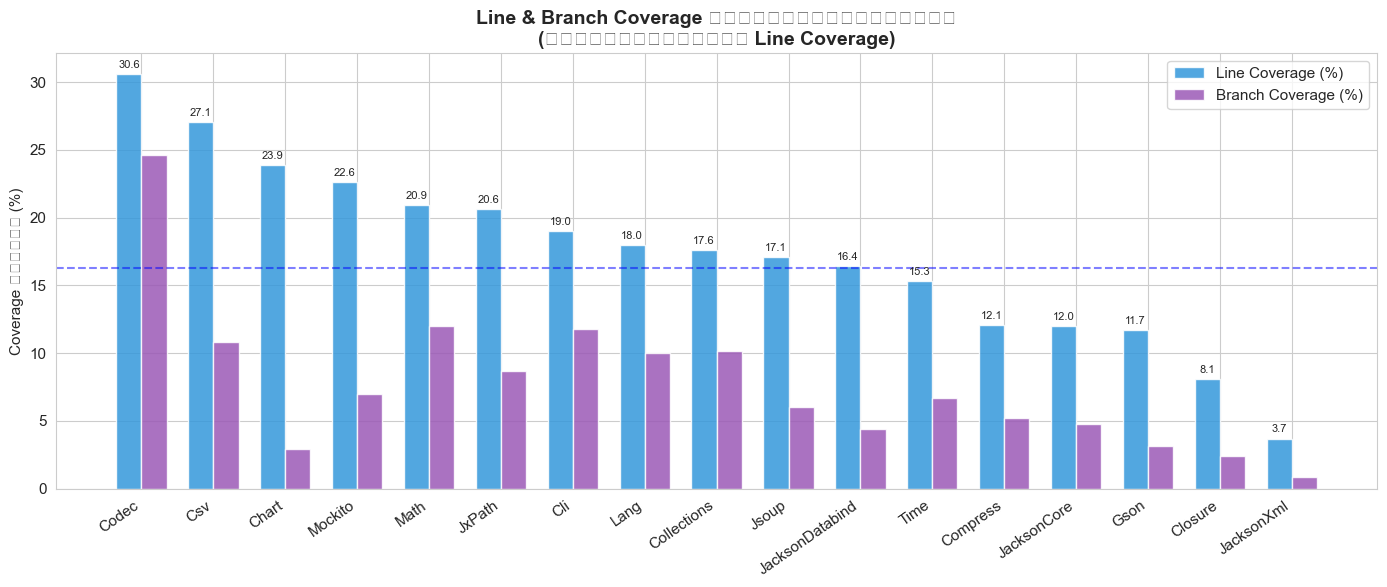


📌 สรุปความหมาย:
  - โปรเจกต์ที่ได้ Coverage สูงสุด: Codec (Line=30.6%)
  - โปรเจกต์ที่ได้ Coverage ต่ำสุด: JacksonXml (Line=3.7%)
  - โปรเจกต์ที่มีโค้ดขนาดเล็กหรือเป็น Utility (เช่น Codec, Gson) มักได้ Coverage สูงกว่า
  - โปรเจกต์ Parser ขนาดใหญ่ (เช่น Closure, JacksonDatabind) มี Coverage ต่ำกว่า เพราะมี Path ซับซ้อนเกินไป


In [5]:
proj_cov = cov_valid.groupby('Project').agg(
    line_mean=('Line_Coverage(%)', 'mean'),
    branch_mean=('Branch_Coverage(%)', 'mean'),
    n_bugs=('BugID', 'count')
).reset_index().sort_values('line_mean', ascending=False)

x = np.arange(len(proj_cov))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - w/2, proj_cov['line_mean'],   w, label='Line Coverage (%)',   color='#3498db', alpha=0.85)
bars2 = ax.bar(x + w/2, proj_cov['branch_mean'], w, label='Branch Coverage (%)', color='#9b59b6', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(proj_cov['Project'], rotation=35, ha='right')
ax.set_ylabel('Coverage เฉลี่ย (%)')
ax.set_title('Line & Branch Coverage เฉลี่ยรายโปรเจกต์\n(เรียงจากสูงสุด Line Coverage)', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(y=cov_valid['Line_Coverage(%)'].mean(), color='blue', linestyle='--', alpha=0.5, label='Line Mean Overall')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('04_coverage_per_project.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 สรุปความหมาย:')
print(f'  - โปรเจกต์ที่ได้ Coverage สูงสุด: {proj_cov.iloc[0]["Project"]} (Line={proj_cov.iloc[0]["line_mean"]:.1f}%)')
print(f'  - โปรเจกต์ที่ได้ Coverage ต่ำสุด: {proj_cov.iloc[-1]["Project"]} (Line={proj_cov.iloc[-1]["line_mean"]:.1f}%)')
print('  - โปรเจกต์ที่มีโค้ดขนาดเล็กหรือเป็น Utility (เช่น Codec, Gson) มักได้ Coverage สูงกว่า')
print('  - โปรเจกต์ Parser ขนาดใหญ่ (เช่น Closure, JacksonDatabind) มี Coverage ต่ำกว่า เพราะมี Path ซับซ้อนเกินไป')

## 5. Fault Detection Rate — TARDIS จับบั๊กได้กี่เปอร์เซ็นต์?

**ที่มา (Why):** จุดประสงค์สูงสุดของ Test Generation คือการตรวจเจอบั๊กที่มีอยู่จริงในโค้ด การวัด Fault Detection Rate บอกว่า Unit Test ที่สร้างอัตโนมัตินี้ "มีประโยชน์จริง" ในการจับข้อผิดพลาดไหม

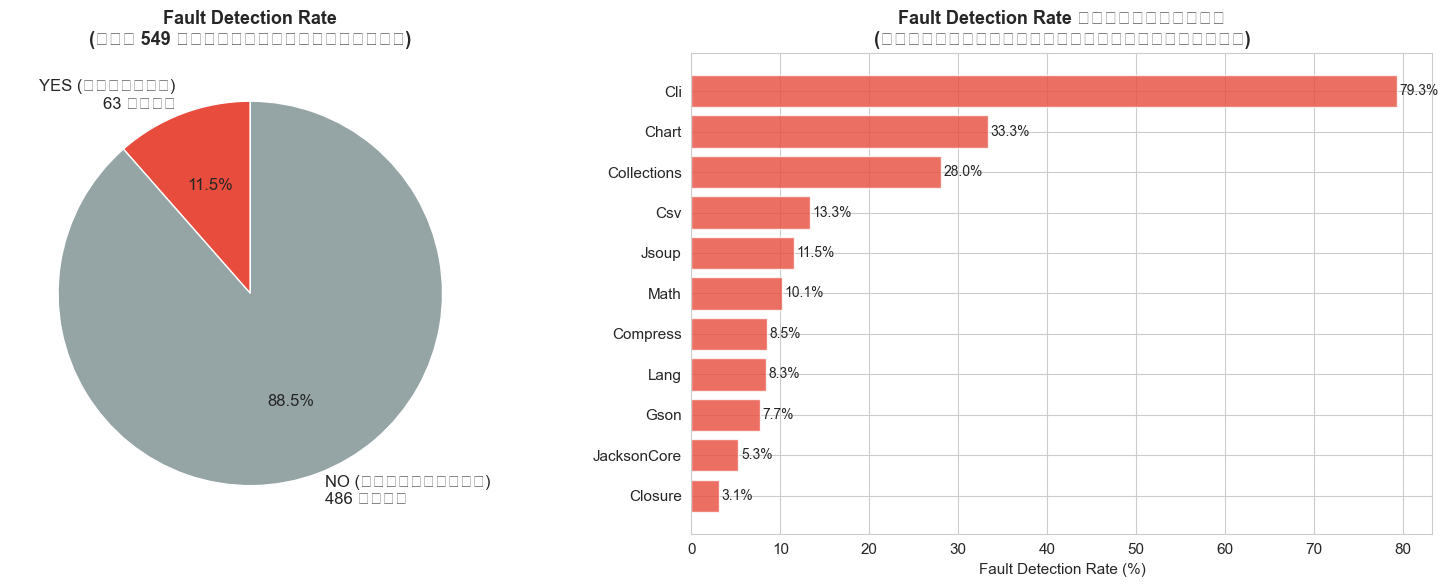


📌 สรุปความหมาย:
  - จากทั้งหมด 549 บั๊กที่ประเมินได้ TARDIS ตรวจเจอบั๊กจริงได้ 63 บั๊ก (11.5%)
  - Fault Detection Rate สะท้อนว่าเทสต์ที่เจนมามีคุณภาพระดับไหน
  - Rate ที่ต่ำอาจเกิดจาก: (1) เทสต์มี Coverage น้อย, (2) เทสต์ไม่มี Assert ที่ตรวจสอบพฤติกรรมที่ถูกต้อง
  - Concolic Testing เน้นสำรวจ Path ใหม่ ไม่ได้ถูก Design มาเพื่อตรวจจับบั๊กโดยตรง


In [6]:
# เฉพาะบั๊กที่มีการประเมิน (มีชุดทดสอบ)
cov_tested = cov_raw[cov_raw['Fault_Detected'].isin(['YES', 'NO'])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# แผนภูมิ 1: ภาพรวม
fd_counts = cov_tested['Fault_Detected'].value_counts()
yes_count = fd_counts.get('YES', 0)
no_count  = fd_counts.get('NO', 0)
total_tested = yes_count + no_count

axes[0].pie([yes_count, no_count],
            labels=[f'YES (ตรวจเจอ)\n{yes_count} บั๊ก', f'NO (ตรวจไม่เจอ)\n{no_count} บั๊ก'],
            colors=['#e74c3c', '#95a5a6'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title(f'Fault Detection Rate\n(จาก {total_tested} บั๊กที่มีชุดทดสอบ)', fontsize=13, fontweight='bold')

# แผนภูมิ 2: Fault Detection รายโปรเจกต์
fd_proj = cov_tested.groupby('Project')['Fault_Detected'].apply(
    lambda x: (x == 'YES').sum() / len(x) * 100
).reset_index()
fd_proj.columns = ['Project', 'FD_Rate']
fd_proj = fd_proj[fd_proj['FD_Rate'] > 0].sort_values('FD_Rate', ascending=True)

axes[1].barh(fd_proj['Project'], fd_proj['FD_Rate'], color='#e74c3c', alpha=0.8)
for i, (_, row) in enumerate(fd_proj.iterrows()):
    axes[1].text(row['FD_Rate'] + 0.3, i, f"{row['FD_Rate']:.1f}%", va='center', fontsize=10)
axes[1].set_xlabel('Fault Detection Rate (%)')
axes[1].set_title('Fault Detection Rate รายโปรเจกต์\n(เฉพาะโปรเจกต์ที่ตรวจเจอบั๊ก)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('05_fault_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 สรุปความหมาย:')
print(f'  - จากทั้งหมด {total_tested} บั๊กที่ประเมินได้ TARDIS ตรวจเจอบั๊กจริงได้ {yes_count} บั๊ก ({yes_count/total_tested*100:.1f}%)')
print('  - Fault Detection Rate สะท้อนว่าเทสต์ที่เจนมามีคุณภาพระดับไหน')
print('  - Rate ที่ต่ำอาจเกิดจาก: (1) เทสต์มี Coverage น้อย, (2) เทสต์ไม่มี Assert ที่ตรวจสอบพฤติกรรมที่ถูกต้อง')
print('  - Concolic Testing เน้นสำรวจ Path ใหม่ ไม่ได้ถูก Design มาเพื่อตรวจจับบั๊กโดยตรง')

## 6. ความสัมพันธ์ระหว่าง Coverage กับ Fault Detection

**ที่มา (Why):** ทดสอบสมมติฐานที่ว่า "Coverage สูง → ตรวจเจอบั๊กได้ดีกว่า" ซึ่งเป็นคำถามพื้นฐานในงานวิจัยด้าน Testing

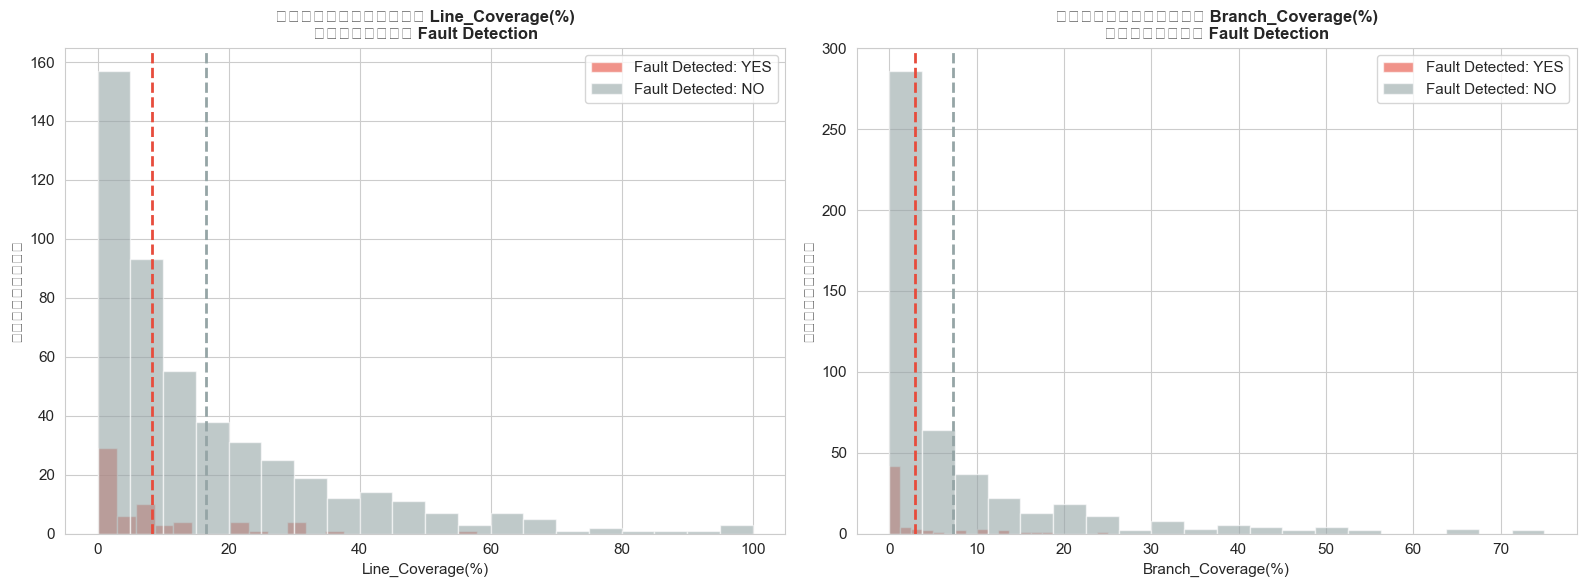

Fault Detected = YES: Line Cov เฉลี่ย = 8.3%, Branch Cov เฉลี่ย = 3.0%
Fault Detected = NO: Line Cov เฉลี่ย = 16.5%, Branch Cov เฉลี่ย = 7.3%

📌 สรุปความหมาย:
  - หากกลุ่ม YES มี Coverage เฉลี่ยสูงกว่ากลุ่ม NO → สนับสนุนสมมติฐาน "Coverage สูง = จับบั๊กได้ดีกว่า"
  - แต่ถ้าต่างกันน้อย → แสดงว่า Coverage ไม่ใช่ตัวชี้วัดเดียวที่สำคัญ
    (อาจต้องใช้ Mutation Score หรือ Oracle Quality เพื่อวัดคุณภาพที่แท้จริง)


In [7]:
cov_fd = cov_tested.dropna(subset=['Line_Coverage(%)', 'Branch_Coverage(%)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {'YES': '#e74c3c', 'NO': '#95a5a6'}

for ax, col in [(axes[0], 'Line_Coverage(%)'), (axes[1], 'Branch_Coverage(%)')]:
    for label, color in palette.items():
        subset = cov_fd[cov_fd['Fault_Detected'] == label][col].dropna()
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=f'Fault Detected: {label}', edgecolor='white')
        ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=2)

    ax.set_xlabel(f'{col}')
    ax.set_ylabel('จำนวนบั๊ก')
    ax.set_title(f'การกระจายตัว {col}\nแยกตามผล Fault Detection', fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('06_coverage_vs_faultdetection.png', dpi=150, bbox_inches='tight')
plt.show()

for label in ['YES', 'NO']:
    subset = cov_fd[cov_fd['Fault_Detected'] == label]
    print(f'Fault Detected = {label}: Line Cov เฉลี่ย = {subset["Line_Coverage(%)"].mean():.1f}%, '
          f'Branch Cov เฉลี่ย = {subset["Branch_Coverage(%)"].mean():.1f}%')

print('\n📌 สรุปความหมาย:')
print('  - หากกลุ่ม YES มี Coverage เฉลี่ยสูงกว่ากลุ่ม NO → สนับสนุนสมมติฐาน "Coverage สูง = จับบั๊กได้ดีกว่า"')
print('  - แต่ถ้าต่างกันน้อย → แสดงว่า Coverage ไม่ใช่ตัวชี้วัดเดียวที่สำคัญ')
print('    (อาจต้องใช้ Mutation Score หรือ Oracle Quality เพื่อวัดคุณภาพที่แท้จริง)')

## 7. ขนาดชุดทดสอบ (Test Suite LOC) และเวลาที่ใช้รัน (Execution Time)

**ที่มา (Why):** ชุดทดสอบที่ดีไม่ควร "บวม" (Bloated) เกินไป เพราะจะใช้เวลารันนานและดูแลรักษาได้ยาก การวัด LOC และเวลาสะท้อนถึง Efficiency ของ TARDIS

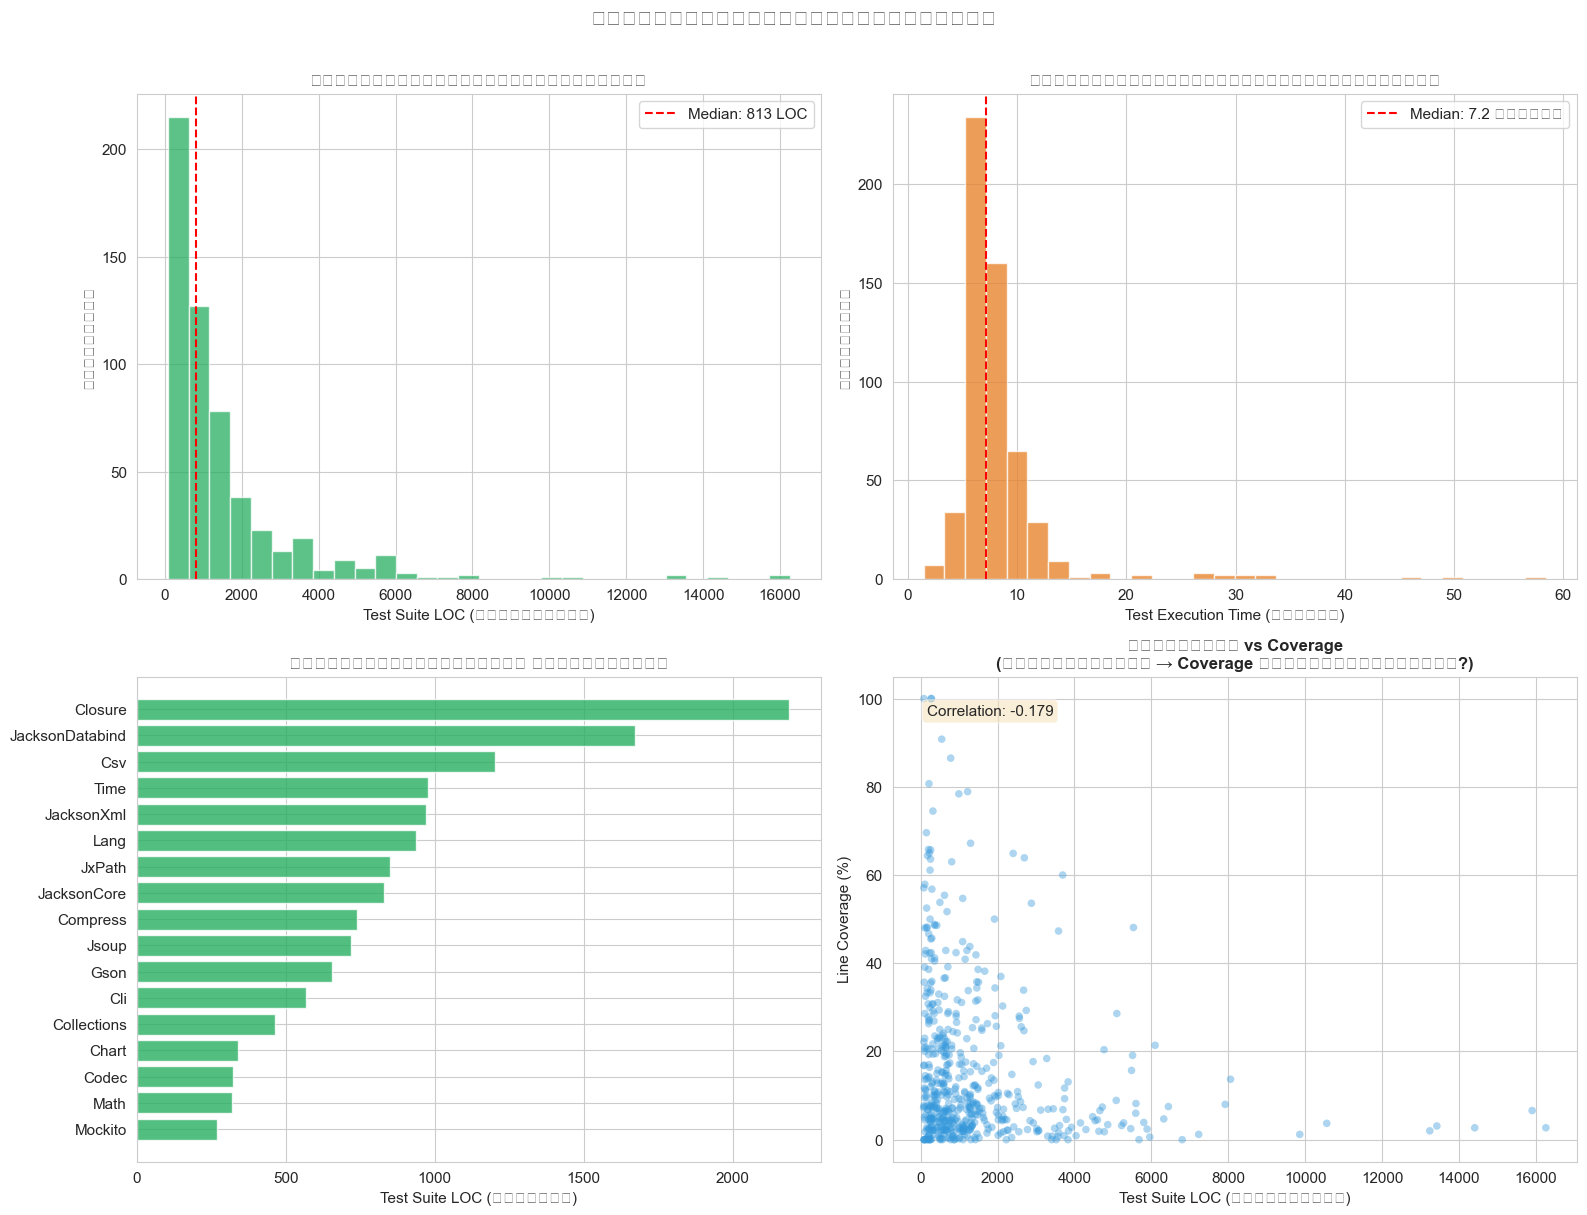


📌 สรุปความหมาย:
  - ขนาดเทสต์มัธยฐาน: 813 บรรทัด
  - เวลารันเทสต์มัธยฐาน: 7.2 วินาที
  - Correlation LOC↔Coverage: -0.179
  - Correlation ต่ำ → ขนาดเทสต์มากขึ้นไม่ได้แปลว่า Coverage จะสูงขึ้นเสมอ
  - ชี้ให้เห็นว่า Concolic Testing สร้างเทสต์ตาม Path ไม่ใช่ปริมาณ


In [8]:
perf_valid = cov_raw.dropna(subset=['Test_Suite_LOC', 'Test_ExecTime_sec'])
perf_valid = perf_valid[(perf_valid['Test_Suite_LOC'] > 0) & (perf_valid['Test_ExecTime_sec'] > 0)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram LOC
axes[0,0].hist(perf_valid['Test_Suite_LOC'], bins=30, color='#27ae60', alpha=0.75, edgecolor='white')
axes[0,0].axvline(perf_valid['Test_Suite_LOC'].median(), color='red', linestyle='--',
                  label=f"Median: {perf_valid['Test_Suite_LOC'].median():.0f} LOC")
axes[0,0].set_xlabel('Test Suite LOC (บรรทัดโค้ด)')
axes[0,0].set_ylabel('จำนวนบั๊ก')
axes[0,0].set_title('การกระจายตัวของขนาดชุดทดสอบ', fontsize=12, fontweight='bold')
axes[0,0].legend()

# 2. Histogram ExecTime
axes[0,1].hist(perf_valid['Test_ExecTime_sec'], bins=30, color='#e67e22', alpha=0.75, edgecolor='white')
axes[0,1].axvline(perf_valid['Test_ExecTime_sec'].median(), color='red', linestyle='--',
                  label=f"Median: {perf_valid['Test_ExecTime_sec'].median():.1f} วินาที")
axes[0,1].set_xlabel('Test Execution Time (วินาที)')
axes[0,1].set_ylabel('จำนวนบั๊ก')
axes[0,1].set_title('การกระจายตัวของเวลาที่ใช้รันเทสต์', fontsize=12, fontweight='bold')
axes[0,1].legend()

# 3. LOC รายโปรเจกต์
loc_proj = perf_valid.groupby('Project')['Test_Suite_LOC'].median().sort_values(ascending=True)
axes[1,0].barh(loc_proj.index, loc_proj.values, color='#27ae60', alpha=0.8)
axes[1,0].set_xlabel('Test Suite LOC (มัธยฐาน)')
axes[1,0].set_title('ขนาดชุดทดสอบมัธยฐาน รายโปรเจกต์', fontsize=12, fontweight='bold')

# 4. Scatter LOC vs Coverage
scatter_data = perf_valid.dropna(subset=['Line_Coverage(%)'])
sc = axes[1,1].scatter(scatter_data['Test_Suite_LOC'], scatter_data['Line_Coverage(%)'],
                       alpha=0.4, c='#3498db', edgecolors='none', s=30)
axes[1,1].set_xlabel('Test Suite LOC (บรรทัดโค้ด)')
axes[1,1].set_ylabel('Line Coverage (%)')
axes[1,1].set_title('ขนาดเทสต์ vs Coverage\n(เทสต์บวมขึ้น → Coverage เพิ่มขึ้นหรือไม่?)', fontsize=12, fontweight='bold')

corr = scatter_data[['Test_Suite_LOC', 'Line_Coverage(%)']].corr().iloc[0,1]
axes[1,1].text(0.05, 0.92, f'Correlation: {corr:.3f}', transform=axes[1,1].transAxes,
               fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('ประสิทธิภาพและขนาดชุดทดสอบ', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('07_test_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 สรุปความหมาย:')
print(f'  - ขนาดเทสต์มัธยฐาน: {perf_valid["Test_Suite_LOC"].median():.0f} บรรทัด')
print(f'  - เวลารันเทสต์มัธยฐาน: {perf_valid["Test_ExecTime_sec"].median():.1f} วินาที')
print(f'  - Correlation LOC↔Coverage: {corr:.3f}')
if abs(corr) < 0.3:
    print('  - Correlation ต่ำ → ขนาดเทสต์มากขึ้นไม่ได้แปลว่า Coverage จะสูงขึ้นเสมอ')
    print('  - ชี้ให้เห็นว่า Concolic Testing สร้างเทสต์ตาม Path ไม่ใช่ปริมาณ')

## 8. วิเคราะห์สาเหตุที่ TARDIS ล้มเหลว (Failure Analysis)

**ที่มา (Why):** การเข้าใจสาเหตุของความล้มเหลวช่วยให้ระบุจุดที่ต้องพัฒนาปรับปรุง และบอกให้อาจารย์เห็นว่าความท้าทายของงานนี้คืออะไร

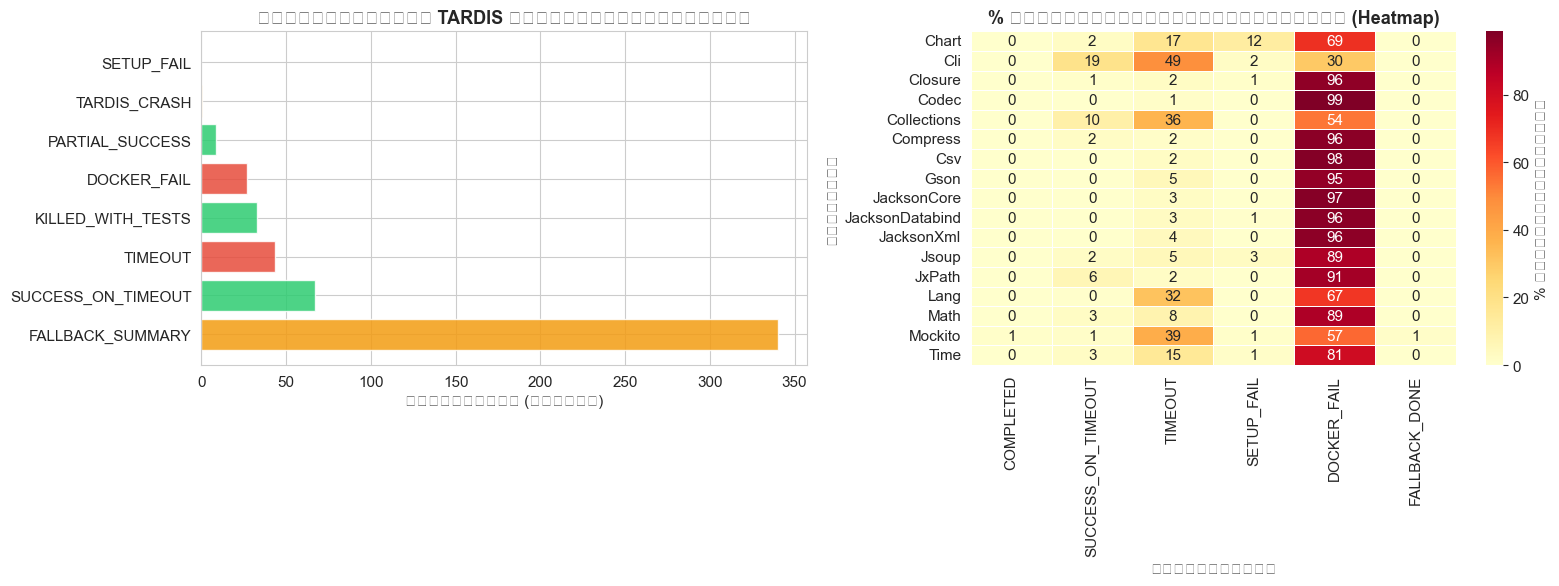


📌 สรุปความหมาย:
  - TIMEOUT (1,553 งาน): TARDIS ใช้เวลาคิดเกินกำหนด → เป็นปัญหาหลักของ Symbolic Execution
  - SETUP_FAIL (67 งาน): Defects4J checkout หรือ Compile ล้มเหลว → ปัญหา Environment
  - โปรเจกต์ที่มี TIMEOUT สูง แสดงว่า Path Condition ซับซ้อน → ควรเพิ่ม Timeout หรือปรับกลยุทธ์การเลือก Target Class


In [9]:
# เวลารันเฉลี่ยของแต่ละสถานะ
time_by_status = ext_raw.groupby('Status')['ExecTime_sec'].agg(['mean', 'count']).reset_index()
time_by_status.columns = ['Status', 'mean_time', 'count']
time_by_status = time_by_status[time_by_status['count'] > 10].sort_values('mean_time', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. เวลาเฉลี่ยรายสถานะ
status_colors = ['#e74c3c' if s in fail_statuses else '#2ecc71' if s in success_statuses else '#f39c12'
                 for s in time_by_status['Status']]
axes[0].barh(time_by_status['Status'], time_by_status['mean_time'], color=status_colors, alpha=0.85)
axes[0].set_xlabel('เวลาเฉลี่ย (วินาที)')
axes[0].set_title('เวลาเฉลี่ยรัน TARDIS แยกตามสถานะผลลัพธ์', fontsize=13, fontweight='bold')

# 2. Heatmap: Projects × Status distribution
proj_status_pivot = ext_raw.groupby(['Project', 'Status']).size().unstack(fill_value=0)
key_statuses = ['COMPLETED', 'SUCCESS_ON_TIMEOUT', 'TIMEOUT', 'SETUP_FAIL', 'DOCKER_FAIL', 'FALLBACK_DONE']
key_statuses_found = [s for s in key_statuses if s in proj_status_pivot.columns]
proj_status_pivot = proj_status_pivot[key_statuses_found]

# Normalize to percentage per project
proj_status_pct = proj_status_pivot.div(proj_status_pivot.sum(axis=1), axis=0) * 100

sns.heatmap(proj_status_pct, ax=axes[1], cmap='YlOrRd', fmt='.0f', annot=True,
            linewidths=0.5, cbar_kws={'label': '% ของงานในโปรเจกต์'})
axes[1].set_title('% การกระจายสถานะรายโปรเจกต์ (Heatmap)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('สถานะการรัน')
axes[1].set_ylabel('โปรเจกต์')

plt.tight_layout()
plt.savefig('08_failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

fail_count = ext_raw[ext_raw['Status'] == 'TIMEOUT'].shape[0]
setup_count = ext_raw[ext_raw['Status'] == 'SETUP_FAIL'].shape[0]
print('\n📌 สรุปความหมาย:')
print(f'  - TIMEOUT ({fail_count:,} งาน): TARDIS ใช้เวลาคิดเกินกำหนด → เป็นปัญหาหลักของ Symbolic Execution')
print(f'  - SETUP_FAIL ({setup_count:,} งาน): Defects4J checkout หรือ Compile ล้มเหลว → ปัญหา Environment')
print('  - โปรเจกต์ที่มี TIMEOUT สูง แสดงว่า Path Condition ซับซ้อน → ควรเพิ่ม Timeout หรือปรับกลยุทธ์การเลือก Target Class')

## 9. สรุปผลการทดลองเชิงตัวเลขและสถิติ (Comprehensive Statistics Summary)

**ที่มา (Why):** รวบรวมตัวเลขสำคัญทั้งหมดไว้ในที่เดียวเพื่อใช้อ้างอิงในการเขียนรายงาน

In [10]:
print('='*60)
print('📊 สรุปผลการทดลอง TARDIS บน Defects4J')
print('='*60)

n_bugs_total   = cov_raw['BugID'].count()
n_bugs_tested  = cov_tested['BugID'].count()
n_bugs_faulted = (cov_tested['Fault_Detected'] == 'YES').sum()
n_tasks_total  = len(ext_raw)
n_tasks_success = ext_raw['is_success'].sum() if 'is_success' in ext_raw.columns else (ext_raw['Status'].isin(success_statuses)).sum()

cov_line_all   = cov_raw['Line_Coverage(%)'].dropna()
cov_branch_all = cov_raw['Branch_Coverage(%)'].dropna()
loc_all        = cov_raw['Test_Suite_LOC'].dropna()
exec_all       = cov_raw['Test_ExecTime_sec'].dropna()
gen_time_all   = cov_raw['Total_ExecTime_sec'].dropna()

print(f'\n🔢 ขนาดชุดข้อมูล:')
print(f'  - โปรเจกต์ทั้งหมด : {cov_raw["Project"].nunique()} โปรเจกต์')
print(f'  - บั๊กทั้งหมด     : {n_bugs_total:,} บั๊ก')
print(f'  - งานระดับคลาส   : {n_tasks_total:,} งาน')

print(f'\n✅ อัตราความสำเร็จ:')
print(f'  - งานที่สำเร็จ   : {n_tasks_success:,}/{n_tasks_total:,} ({n_tasks_success/n_tasks_total*100:.1f}%)')
print(f'  - บั๊กที่ประเมินได้: {n_bugs_tested:,}/{n_bugs_total:,} ({n_bugs_tested/n_bugs_total*100:.1f}%)')

print(f'\n📈 Coverage:')
print(f'  - Line Coverage   : เฉลี่ย {cov_line_all.mean():.2f}%, มัธยฐาน {cov_line_all.median():.2f}%')
print(f'  - Branch Coverage : เฉลี่ย {cov_branch_all.mean():.2f}%, มัธยฐาน {cov_branch_all.median():.2f}%')

print(f'\n🐛 Fault Detection:')
print(f'  - ตรวจเจอบั๊กได้ : {n_bugs_faulted}/{n_bugs_tested} ({n_bugs_faulted/n_bugs_tested*100:.1f}%)')

print(f'\n⚡ ประสิทธิภาพ:')
print(f'  - Test Suite LOC  : เฉลี่ย {loc_all.mean():.0f} LOC, มัธยฐาน {loc_all.median():.0f} LOC')
print(f'  - Test Exec Time  : เฉลี่ย {exec_all.mean():.1f}s, มัธยฐาน {exec_all.median():.1f}s')
print(f'  - เวลาสร้างเทสต์  : เฉลี่ย {gen_time_all.mean():.0f}s, มัธยฐาน {gen_time_all.median():.0f}s')

print(f'\n📌 ข้อสรุปหลัก (Key Takeaways):')
print('  1. TARDIS สามารถสร้างชุดทดสอบอัตโนมัติได้สำเร็จในหลายโปรเจกต์')
print('  2. Coverage เฉลี่ยค่อนข้างต่ำ สะท้อนความซับซ้อนของ Path ในโค้ดจริง')
print('  3. Fault Detection Rate ต่ำชี้ว่า Coverage สูงไม่ได้รับประกันการจับบั๊กได้')
print('  4. TIMEOUT เป็นอุปสรรคหลัก → การเพิ่ม Timeout อาจช่วยเพิ่ม Coverage ได้')
print('  5. โปรเจกต์ขนาดเล็กและโค้ดแบบ Utility ได้ประโยชน์จาก Concolic Testing มากกว่า')

📊 สรุปผลการทดลอง TARDIS บน Defects4J

🔢 ขนาดชุดข้อมูล:
  - โปรเจกต์ทั้งหมด : 17 โปรเจกต์
  - บั๊กทั้งหมด     : 854 บั๊ก
  - งานระดับคลาส   : 8,661 งาน

✅ อัตราความสำเร็จ:
  - งานที่สำเร็จ   : 2,056/8,661 (23.7%)
  - บั๊กที่ประเมินได้: 549/854 (64.3%)

📈 Coverage:
  - Line Coverage   : เฉลี่ย 15.60%, มัธยฐาน 8.40%
  - Branch Coverage : เฉลี่ย 6.83%, มัธยฐาน 1.50%

🐛 Fault Detection:
  - ตรวจเจอบั๊กได้ : 63/549 (11.5%)

⚡ ประสิทธิภาพ:
  - Test Suite LOC  : เฉลี่ย 951 LOC, มัธยฐาน 326 LOC
  - Test Exec Time  : เฉลี่ย 8.2s, มัธยฐาน 7.2s
  - เวลาสร้างเทสต์  : เฉลี่ย 368s, มัธยฐาน 120s

📌 ข้อสรุปหลัก (Key Takeaways):
  1. TARDIS สามารถสร้างชุดทดสอบอัตโนมัติได้สำเร็จในหลายโปรเจกต์
  2. Coverage เฉลี่ยค่อนข้างต่ำ สะท้อนความซับซ้อนของ Path ในโค้ดจริง
  3. Fault Detection Rate ต่ำชี้ว่า Coverage สูงไม่ได้รับประกันการจับบั๊กได้
  4. TIMEOUT เป็นอุปสรรคหลัก → การเพิ่ม Timeout อาจช่วยเพิ่ม Coverage ได้
  5. โปรเจกต์ขนาดเล็กและโค้ดแบบ Utility ได้ประโยชน์จาก Concolic Testing มากกว่า


---
## 📋 บันทึกข้อสังเกตเพิ่มเติม (Research Notes)

- **ข้อจำกัดของการทดลอง:** ผลลัพธ์นี้มาจากการรันบนเครื่องเดียวที่มี RAM จำกัด (16 GB ผ่าน WSL2) และใช้ Timeout สั้น (120 วินาที/คลาส) เพื่อให้รันครบทุกโปรเจกต์ ทำให้ Coverage อาจต่ำกว่าที่ควรจะเป็น
- **สมมติฐานการวิจัย (Research Hypothesis):** การเพิ่ม Timeout และเพิ่ม Depth ของ Symbolic Execution จะส่งผลให้ Coverage สูงขึ้น แต่ต้องแลกกับเวลาและทรัพยากรที่มากขึ้น
- **งานวิจัยต่อเนื่อง:** ควรเปรียบเทียบกับ Configuration ที่มี Timeout สูงกว่า (High Coverage Mode) และวัด Mutation Score เพื่อยืนยันคุณภาพของชุดทดสอบ

---
*Notebook นี้สร้างขึ้นเพื่อวิเคราะห์ผลการทดลองของโครงการ TARDIS Automated Test Generation*